# **삼각함수의 합성**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x_sym = sp.symbols('x', real=True)


class Composite:
    def __init__(self, func, name='f'):
        self.func = func
        self.name = name

    def __call__(self, x):
        return self.func(x)

    def __rshift__(self, other):
        combined = lambda x: self.func(other.func(x))
        return Composite(combined, f'{self.name}({other.name}(x))')


sin = Composite(np.sin, 'sin')
double = Composite(lambda t: 2 * t, '2x')

h = sin >> double
print(f'(f ∘ g)(x) = {h.name}')

x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
print(f'h(π/4) = sin(π/2) = {h(np.pi / 4):.4f}')
print(f'direct: sin(π/2) = {np.sin(np.pi / 2):.4f}')

(f ∘ g)(x) = sin(2x(x))
h(π/4) = sin(π/2) = 1.0000
direct: sin(π/2) = 1.0000


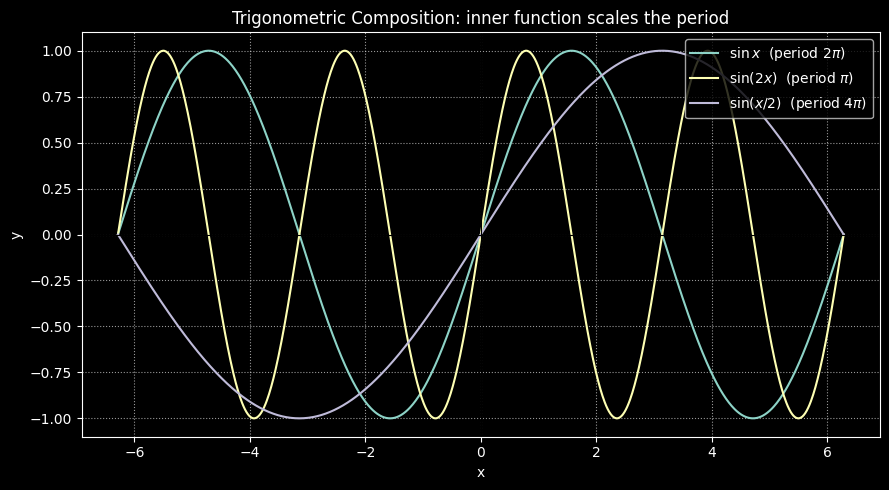

In [2]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.sin(x), label=r'$\sin x$  (period $2\pi$)', linewidth=1.5)
ax.plot(x, np.sin(2 * x), label=r'$\sin(2x)$  (period $\pi$)', linewidth=1.5)
ax.plot(x, np.sin(x / 2), label=r'$\sin(x/2)$  (period $4\pi$)', linewidth=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Trigonometric Composition: inner function scales the period')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [4]:
# 연쇄법칙 
expr = sp.sin(2 * x_sym)
d_expr = sp.diff(expr, x_sym)

print(f'f(x)  = {expr}')
print(f"f'(x) = {d_expr}")
print("안쪽 함수 2x의 도함수 2가 곱해짐 → (f∘g)'(x) = f'(g(x)) · g'(x)")

for fn, label in [(sp.sin(x_sym ** 2), 'sin(x²)'),
                  (sp.cos(sp.sin(x_sym)), 'cos(sin x)')]:
    print(f"\n{label}: d/dx = {sp.diff(fn, x_sym)}")

f(x)  = sin(2*x)
f'(x) = 2*cos(2*x)
안쪽 함수 2x의 도함수 2가 곱해짐 → (f∘g)'(x) = f'(g(x)) · g'(x)

sin(x²): d/dx = 2*x*cos(x**2)

cos(sin x): d/dx = -sin(sin(x))*cos(x)


In [5]:
# 극한 예고: lim(x→0) sin(3x)/x  (limit_of_function.ipynb 와 연결)
limit_val = sp.limit(sp.sin(3 * x_sym) / x_sym, x_sym, 0)
print(f'lim(x→0) sin(3x)/x = {limit_val}')
print('합성 sin(3x) 덕분에 계수 3이 극한값에 반영')

lim(x→0) sin(3x)/x = 3
합성 sin(3x) 덕분에 계수 3이 극한값에 반영


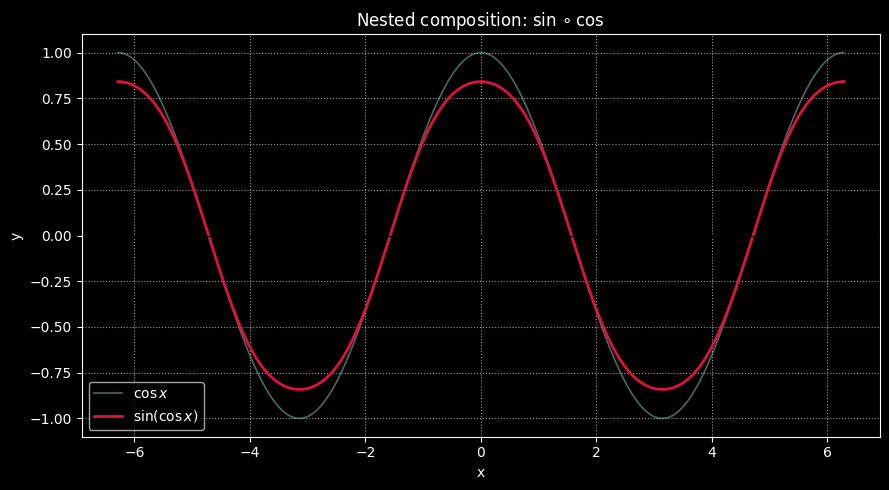

In [6]:
# 중첩 합성: sin(cos x)
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, np.cos(x), label=r'$\cos x$', alpha=0.5, linewidth=1.2)
ax.plot(x, np.sin(np.cos(x)), label=r'$\sin(\cos x)$', color='crimson', linewidth=2)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'Nested composition: $\sin \circ \cos$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()